<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%207/W07_L2_Backpropagation_in_RNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=vZQP26PHNOk) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%207/NPTEL_Jul24_DL4CV_W07_P02.pdf)

In [1]:
# Week 7, Lecture 2: Backprop in RNN's
from IPython.display import HTML, display

VIDEO_ID = "vZQP26PHNOk"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 7, Lecture 2: Backpropagation in RNNs

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§7.2 Backprop in RNNs**.

**What you will learn**

- Backpropagation through time: why the gradient at one step is a **sum over all earlier steps**.
- The closed form $\partial E_3/\partial V = (\hat y_3 - y_3) \otimes h_3$, checked against autograd.
- Why the obvious one-line gradient for $W$ is **wrong**, demonstrated by breaking it deliberately.
- The product of Jacobians $\prod_j \partial h_j/\partial h_{j-1}$, and why it vanishes or explodes.
- Gradient clipping, and why exploding gradients are the easier of the two problems.

**Contents**

1. Forward pass and the loss
2. The easy gradient: $\partial E/\partial V$
3. The gradient for $W$, and why one term is not enough
4. Backpropagation through time
5. Vanishing and exploding gradients
6. Explore and verify

**How to run**  Everything is tiny and runs in seconds on **Colab CPU or GPU** (no GPU needed). Run the setup cell first, then go top to bottom.

## Review

The previous lecture built the recurrence $h_t = \tanh(Ux_t + Wh_{t-1})$ and showed that the
same parameters are reused at every step. That reuse is exactly what makes the backward pass
interesting: a weight matrix that appears at every time step collects gradient from every
time step.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
print('torch', torch.__version__, '| device:', device)

torch 2.8.0 | device: cpu


## 1. Forward pass and the loss

$$h_t = \tanh(U x_t + W h_{t-1}), \qquad \hat y_t = \mathrm{softmax}(V h_t)$$

With cross entropy at each step, and the total error the sum over steps:

$$E_t(y_t, \hat y_t) = -y_t \log \hat y_t, \qquad E = \sum_t E_t = -\sum_t y_t \log \hat y_t$$

Because $E$ is a sum, and gradients are linear, the total gradient is also a sum:

$$\frac{\partial E}{\partial W} = \sum_t \frac{\partial E_t}{\partial W}$$

In [3]:
# A small RNN we can differentiate by hand and against autograd.
D, H, C, T = 3, 4, 5, 4                      # input, hidden, classes, timesteps

U = torch.randn(H, D, requires_grad=True)
W = torch.randn(H, H, requires_grad=True) * 0.5
V = torch.randn(C, H, requires_grad=True)
W = W.detach().requires_grad_(True)

xs = torch.randn(T, D)
ys = torch.randint(0, C, (T,))

def forward(U, W, V, xs):
    h = torch.zeros(H)
    hs, logits = [], []
    for x in xs:
        h = torch.tanh(U @ x + W @ h)
        hs.append(h); logits.append(V @ h)
    return hs, torch.stack(logits)

hs, logits = forward(U, W, V, xs)
per_step = torch.stack([nn.functional.cross_entropy(logits[t][None], ys[t][None]) for t in range(T)])
E = per_step.sum()
print(f'per-step losses: {[round(v, 3) for v in per_step.tolist()]}')
print(f'total E = {E.item():.4f}')

per-step losses: [2.686, 0.162, 4.088, 0.995]
total E = 7.9304


In [4]:
# The gradient of a sum is the sum of gradients: check it.
grad_total = torch.autograd.grad(E, W, retain_graph=True)[0]

grad_sum = torch.zeros_like(W)
for t in range(T):
    hs_t, logits_t = forward(U, W, V, xs)
    E_t = nn.functional.cross_entropy(logits_t[t][None], ys[t][None])
    grad_sum += torch.autograd.grad(E_t, W, retain_graph=True)[0]

assert torch.allclose(grad_total, grad_sum, atol=1e-5), 'sum of per-step gradients disagrees'
print(f'dE/dW from one backward pass vs summing {T} per-step passes:')
print(f'  max |difference| = {(grad_total - grad_sum).abs().max():.2e}')

dE/dW from one backward pass vs summing 4 per-step passes:
  max |difference| = 1.19e-07


## 2. The easy gradient: $\partial E/\partial V$

$V$ appears only at the output of the step in question, so no recurrence is involved. Writing
$z_3 = Vh_3$,

$$\frac{\partial E_3}{\partial V} = \frac{\partial E_3}{\partial \hat y_3}\frac{\partial \hat y_3}{\partial z_3}\frac{\partial z_3}{\partial V} = (\hat y_3 - y_3) \otimes h_3$$

where $\otimes$ is the outer product. The whole gradient depends only on quantities at step 3.

In [5]:
# Verify the closed form against autograd.
t = 2                                        # the deck's "step 3", zero-indexed
E_t = nn.functional.cross_entropy(logits[t][None], ys[t][None])
auto = torch.autograd.grad(E_t, V, retain_graph=True)[0]

yhat = torch.softmax(logits[t], dim=0)
y_onehot = torch.zeros(C); y_onehot[ys[t]] = 1.0
closed_form = torch.outer(yhat - y_onehot, hs[t])

assert torch.allclose(auto, closed_form, atol=1e-6), 'closed form disagrees with autograd'
print(f'(yhat - y) outer h  vs  autograd:  max |difference| = {(auto - closed_form).abs().max():.2e}')
print('the output-layer gradient needs nothing from earlier time steps')

(yhat - y) outer h  vs  autograd:  max |difference| = 2.98e-08
the output-layer gradient needs nothing from earlier time steps


## 3. The gradient for $W$, and why one term is not enough

The obvious thing to write is

$$\frac{\partial E_3}{\partial W} = \frac{\partial E_3}{\partial \hat y_3}\frac{\partial \hat y_3}{\partial h_3}\frac{\partial h_3}{\partial W}$$

and it is **wrong**. It treats $h_2$ as a constant, but $h_2$ was itself produced using $W$.
The chain rule has to be applied again, back through the whole chain.

We can demonstrate the error rather than argue about it: detach the earlier states, so
autograd genuinely does treat them as constants, and compare.

In [6]:
# Deliberately break the recurrence to reproduce the incomplete gradient.
def forward_detached(U, W, V, xs, upto):
    """Same forward pass, but earlier hidden states are detached from the graph."""
    h = torch.zeros(H)
    hs = []
    for i, x in enumerate(xs):
        if i == upto:
            h = h.detach()                   # pretend the previous state did not depend on W
        h = torch.tanh(U @ x + W @ h)
        hs.append(h)
    return hs

t = 2
hs_full = forward(U, W, V, xs)[0]
E_full = nn.functional.cross_entropy((V @ hs_full[t])[None], ys[t][None])
grad_full = torch.autograd.grad(E_full, W, retain_graph=True)[0]

hs_cut = forward_detached(U, W, V, xs, upto=t)
E_cut = nn.functional.cross_entropy((V @ hs_cut[t])[None], ys[t][None])
grad_cut = torch.autograd.grad(E_cut, W, retain_graph=True)[0]

rel = (grad_full - grad_cut).norm() / grad_full.norm()
assert rel > 0.01, 'the incomplete gradient should differ noticeably'
print(f'full gradient norm       : {grad_full.norm():.5f}')
print(f'incomplete gradient norm : {grad_cut.norm():.5f}')
print(f'relative difference      : {100 * rel:.1f}%   -> the missing terms matter')

full gradient norm       : 2.71317
incomplete gradient norm : 2.69711
relative difference      : 33.2%   -> the missing terms matter


## 4. Backpropagation through time

Because $h_3$ depends on $W$ directly *and* indirectly through $h_2, h_1, h_0$, the gradient
sums over every earlier step:

$$\frac{\partial E_3}{\partial W} = \sum_{k=0}^{3} \frac{\partial E_3}{\partial \hat y_3}\frac{\partial \hat y_3}{\partial h_3}\frac{\partial h_3}{\partial h_k}\frac{\partial h_k}{\partial W}$$

and the middle factor itself expands into a **product of Jacobians**:

$$\frac{\partial h_3}{\partial h_k} = \prod_{j=k+1}^{3}\frac{\partial h_j}{\partial h_{j-1}}$$

For our recurrence that Jacobian has a closed form the slides do not write out. Since
$h_j = \tanh(Ux_j + Wh_{j-1})$ and $\tanh' = 1 - \tanh^2$,

$$\frac{\partial h_j}{\partial h_{j-1}} = \mathrm{diag}\!\left(1 - h_j^2\right) W$$

In [7]:
# Verify the Jacobian closed form, and that Jacobians compose.
from torch.autograd.functional import jacobian

def step(h_prev, x):
    return torch.tanh(U @ x + W @ h_prev)

h_prev = hs[0].detach()
J_auto = jacobian(lambda h: step(h, xs[1]), h_prev)
h_next = step(h_prev, xs[1])
J_closed = torch.diag(1 - h_next ** 2) @ W

assert torch.allclose(J_auto, J_closed, atol=1e-5), 'Jacobian closed form is wrong'
print(f'diag(1 - h^2) W  vs  autograd Jacobian: max |difference| = {(J_auto - J_closed).abs().max():.2e}')

# Jacobians compose: dh3/dh1 == dh3/dh2 @ dh2/dh1
h1 = hs[1].detach()
J21 = jacobian(lambda h: step(h, xs[2]), h1)
h2 = step(h1, xs[2])
J32 = jacobian(lambda h: step(h, xs[3]), h2)
J31 = jacobian(lambda h: step(step(h, xs[2]), xs[3]), h1)

assert torch.allclose(J31, J32 @ J21, atol=1e-5), 'Jacobians do not compose'
print(f'dh3/dh1 vs (dh3/dh2)(dh2/dh1):          max |difference| = {(J31 - J32 @ J21).abs().max():.2e}')

diag(1 - h^2) W  vs  autograd Jacobian: max |difference| = 2.98e-08
dh3/dh1 vs (dh3/dh2)(dh2/dh1):          max |difference| = 2.98e-08


## 5. Vanishing and exploding gradients

Sentences can be twenty words or more, so that product runs over many factors. Each factor
is $\mathrm{diag}(1-h_j^2)W$, and the derivative term is bounded: $\tanh'$ never exceeds 1,
and the logistic sigmoid's derivative never exceeds $0.25$.

Multiply many numbers below 1 and the product goes to zero: **long-range dependencies stop
contributing at all**. That is the vanishing gradient problem, and it is why the next lecture
exists.

If instead the weights are large, the product grows without bound. That is the **exploding
gradient** problem, which the slides note is much less troublesome in practice: it announces
itself as `NaN`, and **gradient clipping** fixes it.

In [8]:
# The activation derivative bounds the whole thing.
z = torch.linspace(-5, 5, 1001)
tanh_prime = 1 - torch.tanh(z) ** 2
sig = torch.sigmoid(z)
sigmoid_prime = sig * (1 - sig)

print(f'max tanh\'(z)    = {tanh_prime.max():.4f}   (attained at z = 0)')
print(f'max sigmoid\'(z) = {sigmoid_prime.max():.4f}   (attained at z = 0)')
assert abs(tanh_prime.max() - 1.0) < 1e-6
assert abs(sigmoid_prime.max() - 0.25) < 1e-6
print('\nthe slides say the gradient is "upper bounded by 1" for sigmoid activations;')
print('that bound is exactly right for tanh, and loose for the logistic sigmoid (0.25)')

max tanh'(z)    = 1.0000   (attained at z = 0)
max sigmoid'(z) = 0.2500   (attained at z = 0)

the slides say the gradient is "upper bounded by 1" for sigmoid activations;
that bound is exactly right for tanh, and loose for the logistic sigmoid (0.25)


In [9]:
# Watch the product of Jacobians decay or explode as the unroll gets longer.
def jacobian_product_norm(scale, T_unroll, seed=0):
    torch.manual_seed(seed)
    Wl = torch.randn(H, H) * scale
    h = torch.zeros(H)
    P = torch.eye(H)
    for t in range(T_unroll):
        h = torch.tanh(Wl @ h + torch.randn(H) * 0.1)
        P = torch.diag(1 - h ** 2) @ Wl @ P
    return P.norm().item()

for scale in (0.5, 1.0, 2.0):
    norms = [jacobian_product_norm(scale, T) for T in (1, 5, 10, 20, 40)]
    print(f'  W scale {scale}:  ' + '  '.join(f'T={T}: {n:9.2e}' for T, n in zip((1,5,10,20,40), norms)))

  W scale 0.5:  T=1:  1.83e+00  T=5:  1.20e+00  T=10:  9.08e-01  T=20:  3.43e-01  T=40:  4.84e-02
  W scale 1.0:  T=1:  3.65e+00  T=5:  2.68e+01  T=10:  1.66e+01  T=20:  3.78e+01  T=40:  2.69e+01
  W scale 2.0:  T=1:  7.30e+00  T=5:  1.38e+01  T=10:  6.92e+00  T=20:  1.21e-01  T=40:  1.13e-05


In [10]:
# Gradient clipping: rescale the gradient when its norm exceeds a threshold.
g = torch.tensor([30.0, 40.0])               # norm 50, far too large
threshold = 5.0
clipped = g * min(1.0, threshold / g.norm())

print(f'gradient      {g.tolist()}  norm {g.norm():.1f}')
print(f'after clipping{clipped.tolist()}  norm {clipped.norm():.1f}')
assert abs(clipped.norm() - threshold) < 1e-5
print('\ndirection is preserved, only the magnitude is capped')

gradient      [30.0, 40.0]  norm 50.0
after clipping[2.999999761581421, 3.999999761581421]  norm 5.0

direction is preserved, only the magnitude is capped


## 6. Explore and verify

The central claim of this lecture is that the full BPTT gradient equals the sum over
earlier steps of a product of Jacobians. We can reconstruct it term by term and compare
against a single autograd call.

In [11]:
# Reconstruct dE_t/dW from the BPTT formula, term by term, and compare with autograd.
t = 3                                        # differentiate the loss at the last step
hs_f, logits_f = forward(U, W, V, xs)
E_t = nn.functional.cross_entropy(logits_f[t][None], ys[t][None])
auto = torch.autograd.grad(E_t, W, retain_graph=True)[0]

# Manual: for each k <= t, take dE/dh_t, push it back to step k through the Jacobians,
# then apply dh_k/dW treating h_{k-1} as a constant.
dE_dht = torch.autograd.grad(E_t, hs_f[t], retain_graph=True)[0]

manual = torch.zeros_like(W)
delta = dE_dht.clone()
for k in range(t, -1, -1):
    h_prev = hs_f[k - 1].detach() if k > 0 else torch.zeros(H)
    pre = U @ xs[k] + W @ h_prev
    local = (1 - torch.tanh(pre) ** 2) * delta          # through the tanh
    manual += torch.outer(local, h_prev)                # dh_k/dW with h_{k-1} held fixed
    delta = W.t() @ local                               # push back one more step

rel = (auto - manual).norm() / auto.norm()
assert rel < 1e-5, f'manual BPTT differs from autograd by {rel:.2e}'
print(f'  autograd gradient norm : {auto.norm():.6f}')
print(f'  manual  BPTT norm      : {manual.norm():.6f}')
print(f'  relative difference    : {rel:.2e}')
print(f'\n  summed over {t + 1} time steps, exactly as the BPTT formula prescribes')

  autograd gradient norm : 0.858264
  manual  BPTT norm      : 0.858264
  relative difference    : 2.75e-08

  summed over 4 time steps, exactly as the BPTT formula prescribes


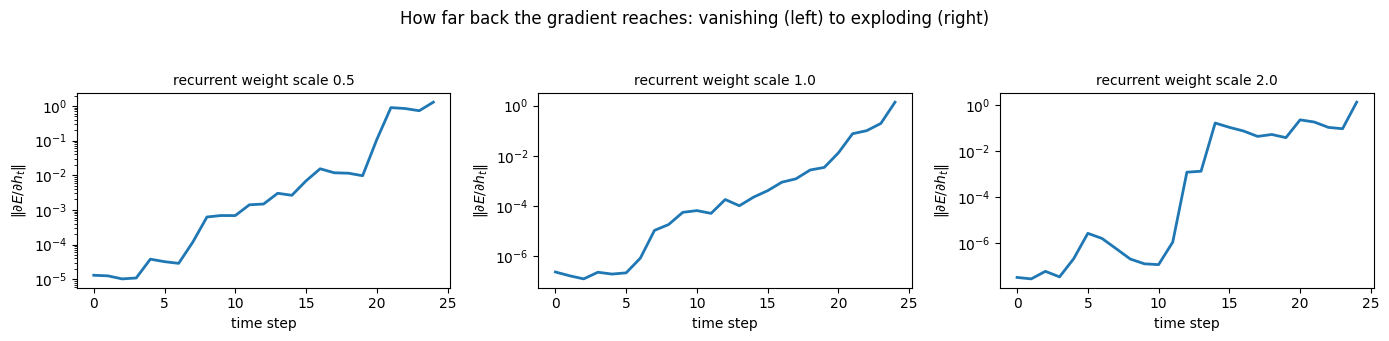

In [12]:
# Static sweep: gradient norm reaching back in time, for three recurrent weight scales.
def reachback(scale, T_unroll=25, seed=0):
    torch.manual_seed(seed)
    Ul = torch.randn(H, D); Wl = torch.randn(H, H) * scale; Vl = torch.randn(C, H)
    Wl.requires_grad_(True)
    xs_l = torch.randn(T_unroll, D)
    h = torch.zeros(H); states = []
    for x in xs_l:
        h = torch.tanh(Ul @ x + Wl @ h); states.append(h)
    loss = nn.functional.cross_entropy((Vl @ states[-1])[None], torch.tensor([0]))
    grads = torch.autograd.grad(loss, states, retain_graph=True, allow_unused=True)
    return [g.norm().item() if g is not None else 0.0 for g in grads]

fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))
for a, scale in zip(ax, [0.5, 1.0, 2.0]):
    n = reachback(scale)
    a.semilogy(range(len(n)), n, lw=2)
    a.set_title(f'recurrent weight scale {scale}', fontsize=10)
    a.set_xlabel('time step'); a.set_ylabel(r'$\|\partial E / \partial h_t\|$')
fig.suptitle('How far back the gradient reaches: vanishing (left) to exploding (right)', y=1.05)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [13]:
# Live: the scale of W decides how far back the gradient survives.
from ipywidgets import interact, FloatSlider, IntSlider

def reach(scale=1.0, T_unroll=25):
    n = reachback(scale, T_unroll)
    fig, a = plt.subplots(figsize=(7.5, 3.4))
    a.semilogy(range(len(n)), n, lw=2)
    a.set_xlabel('time step'); a.set_ylabel(r'$\|\partial E / \partial h_t\|$')
    a.set_title(f'W scale {scale:.2f}: gradient at step 0 is {n[0]:.2e}')
    plt.tight_layout(); plt.show()

interact(reach, scale=FloatSlider(min=0.2, max=2.5, step=0.1, value=1.0),
                T_unroll=IntSlider(min=5, max=50, step=5, value=25));

interactive(children=(FloatSlider(value=1.0, description='scale', max=2.5, min=0.2), IntSlider(value=25, descr…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **BPTT** | $W$ appears at every step, so $\partial E/\partial W = \sum_t \partial E_t/\partial W$ |
| **Output gradient** | $\partial E_3/\partial V = (\hat y_3 - y_3) \otimes h_3$, no recurrence involved |
| **The wrong shortcut** | Treating $h_2$ as constant drops most of the gradient; the chain rule must be reapplied |
| **Sum over $k$** | $\partial E_3/\partial W$ sums contributions from every earlier step $k \le 3$ |
| **Product of Jacobians** | $\partial h_3/\partial h_k = \prod_{j=k+1}^{3} \partial h_j/\partial h_{j-1}$, with $\partial h_j/\partial h_{j-1} = \mathrm{diag}(1-h_j^2)W$ |
| **Vanishing gradients** | $\tanh' \le 1$ and $\sigma' \le 0.25$, so long products decay and long-range dependencies stop contributing |
| **Exploding gradients** | Easier: shows up as `NaN`, and gradient clipping caps the norm while preserving direction |

## Exercises

1. **The homework from the slides.** Derive $\partial E_3/\partial U$ the same way as $\partial E_3/\partial W$, then verify it numerically against autograd exactly as section 6 does for $W$.
2. **Simpler fixes.** The slides ask for solutions to vanishing gradients that do **not** change the RNN architecture. Try each of: ReLU instead of tanh, a smaller initialisation of $W$, and truncating the unroll length. Measure how far back the gradient survives in each case.
3. **Where does clipping bite?** Train the model from section 1 with the recurrent weights scaled up until you see `NaN`, then add clipping and find the largest threshold that still keeps training stable.
4. **Is the bound tight?** The slides say the gradient is "upper bounded by 1" for sigmoid activations. Show that $\max \sigma' = 0.25$, and work out how many steps it takes a sigmoid RNN to lose a factor of $10^{-6}$ compared with a tanh one.
